# **PROJECT 1: Customer Churn Analysis - Telecom Industry** #

## **Columns** ##

Customer churn is a major issue in telecommunications, where retaining customers is significantly more cost-effective than acquiring new ones. \
This dataset contains customer-level details including demographics, services subscribed, billing information, and whether the customer churned.

**CustomerID**: Unique identifier

**Gender**: Male/Female

**SeniorCitizen**: 0 = No, 1 = Yes

**Partner**: Yes/No

**Dependents**: Yes/No

**Tenure**: Number of months with the company

**PhoneService**: Yes/No

**MultipleLines**: Yes/No/No phone service

**InternetService**: DSL/Fiber optic/No

**OnlineSecurity**, **OnlineBackup**, **DeviceProtection**, **TechSupport**, **StreamingTV**, **StreamingMovies**: Yes/No/No internet service

**Contract**: Month-to-month/One year/Two year

**PaperlessBilling**: Yes/No

**PaymentMethod**: Electronic check/Mailed check/Bank transfer/Credit card

**MonthlyCharges**: Amount billed monthly

**TotalCharges**: Lifetime total charges

**Churn**: Yes/No


In [1]:
!python.exe -m pip install --upgrade pip
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Only for Jupyter Lab
!pip install ipympl
!jupyter labextension install @jupyter-widgets/jupyterlab-manager
!jupyter labextension install jupyter-matplotlib

Defaulting to user installation because normal site-packages is not writeable


(Deprecated) Installing extensions with the jupyter labextension install command is now deprecated and will be removed in a future major version of JupyterLab.

Users should manage prebuilt extensions with package managers like pip and conda, and extension authors are encouraged to distribute their extensions as prebuilt packages 
C:\Python313\Lib\site-packages\jupyterlab\debuglog.py:54: UserWarning: An error occurred.
  warnings.warn("An error occurred.")
C:\Python313\Lib\site-packages\jupyterlab\debuglog.py:55: UserWarning: PermissionError: [WinError 5] Access is denied: 'C:\\Python313\\share\\jupyter\\lab\\extensions'
  warnings.warn(msg[-1].strip())
C:\Python313\Lib\site-packages\jupyterlab\debuglog.py:56: UserWarning: See the log file for details: C:\Users\alank\AppData\Local\Temp\jupyterlab-debug-d696sgpg.log
  warnings.warn(f"See the log file for details: {log_path!s}")
(Deprecated) Installing extensions with the jupyter labextension install command is now deprecated and will be

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='whitegrid')

# To clean the plotting cache
plt.close('all')

In [4]:
# Load CSV file
telecom = pd.read_csv('../data/raw/telecom_customer_churn.csv')
assert not telecom.empty, 'Dataset is empty'

In [42]:
# Display basic information on dataset
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"Dataset shape: {telecom.shape}")
print(f"Number of customers: {len(telecom)}")
print(f"Number of features: {len(telecom.columns)}")
print("\nFirst 5 rows:\n")
print(telecom.head())
print("\n" + "="*80)

DATASET OVERVIEW
Dataset shape: (7043, 24)
Number of customers: 7043
Number of features: 24

First 5 rows:

   customerID  gender SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female            No     Yes         No       1           No   
1  5575-GNVDE    Male            No      No         No      34          Yes   
2  3668-QPYBK    Male            No      No         No       2          Yes   
3  7795-CFOCW    Male            No      No         No      45           No   
4  9237-HQITU  Female            No      No         No       2          Yes   

  MultipleLines InternetService OnlineSecurity  ... StreamingMovies  \
0            No             DSL             No  ...              No   
1            No             DSL            Yes  ...              No   
2            No             DSL            Yes  ...              No   
3            No             DSL            Yes  ...              No   
4            No     Fiber optic             No  ...           

In [6]:
# Data Cleaning and Preprocessing
print("="*80)
print("DATA CLEANING AND PREPROCESSING")
print("="*80)

# Check for missing values
print("Missing values per column:\n")
print(telecom.isnull().sum())

DATA CLEANING AND PREPROCESSING
Missing values per column:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
# Handle missing values in TotalCharges (convert to numeric, errors='coerce' will make invalid values NaN)
telecom['TotalCharges'] = pd.to_numeric(telecom['TotalCharges'], errors='coerce')

In [8]:
# Fill missing TotalCharges with 0 (likely new customers)
telecom['TotalCharges'].fillna(0, inplace=True)

In [9]:
# Check unique values in categorical columns
categorical_cols = telecom.select_dtypes(include=['object']).columns
print(f"📈 Unique values in categorical columns:\n")
for col in categorical_cols:
    if col != 'customerID':
        print(f"{col}: {telecom[col].unique()[:5]}... ({len(telecom[col].unique())} unique)")

📈 Unique values in categorical columns:

gender: ['Female' 'Male']... (2 unique)
Partner: ['Yes' 'No']... (2 unique)
Dependents: ['No' 'Yes']... (2 unique)
PhoneService: ['No' 'Yes']... (2 unique)
MultipleLines: ['No phone service' 'No' 'Yes']... (3 unique)
InternetService: ['DSL' 'Fiber optic' 'No']... (3 unique)
OnlineSecurity: ['No' 'Yes' 'No internet service']... (3 unique)
OnlineBackup: ['Yes' 'No' 'No internet service']... (3 unique)
DeviceProtection: ['No' 'Yes' 'No internet service']... (3 unique)
TechSupport: ['No' 'Yes' 'No internet service']... (3 unique)
StreamingTV: ['No' 'Yes' 'No internet service']... (3 unique)
StreamingMovies: ['No' 'Yes' 'No internet service']... (3 unique)
Contract: ['Month-to-month' 'One year' 'Two year']... (3 unique)
PaperlessBilling: ['Yes' 'No']... (2 unique)
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']... (4 unique)
Churn: ['No' 'Yes']... (2 unique)


In [10]:
# Handle 'No internet service' and 'No phone service' - convert to 'No'
for col in telecom.columns:
    if telecom[col].dtype == 'object':
        telecom[col] = telecom[col].replace({
            'No internet service': 'No',
            'No phone service': 'No'
        })

In [11]:
# Create tenure groups
telecom['TenureGroup'] = pd.cut(telecom['tenure'], 
                           bins=[0, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120],
                           labels=['0-1yr', '1-2yr', '2-3yr', '3-4yr', '4-5yr', 
                                  '5-6yr', '6-7yr', '7-8yr', '8-9yr', '9-10yr'])

In [12]:
# Calculate average monthly charge per service
service_columns = ['PhoneService', 'InternetService', 'StreamingTV', 'StreamingMovies']
telecom['ServicesCount'] = telecom[service_columns].apply(lambda x: (x != 'No').sum(), axis=1)
telecom['AvgChargePerService'] = telecom['MonthlyCharges'] / telecom['ServicesCount'].replace(0, 1)

print(f"✅ Final shape: {telecom.shape}")

✅ Final shape: (7043, 24)


In [13]:
# Check data types
print(f"Data types:\n\n{telecom.dtypes}")

Data types:

customerID               object
gender                   object
SeniorCitizen             int64
Partner                  object
Dependents               object
tenure                    int64
PhoneService             object
MultipleLines            object
InternetService          object
OnlineSecurity           object
OnlineBackup             object
DeviceProtection         object
TechSupport              object
StreamingTV              object
StreamingMovies          object
Contract                 object
PaperlessBilling         object
PaymentMethod            object
MonthlyCharges          float64
TotalCharges            float64
Churn                    object
TenureGroup            category
ServicesCount             int64
AvgChargePerService     float64
dtype: object


In [14]:
# Convert SeniorCitizen to categorical for consistency
telecom['SeniorCitizen'] = telecom['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

telecom['SeniorCitizen'].head()

0    No
1    No
2    No
3    No
4    No
Name: SeniorCitizen, dtype: object

In [15]:
# Create a copy for analysis
telecom_clean = telecom.copy()

print(f"Missing values after cleaning:  {telecom_clean.isnull().sum().sum()}")

Missing values after cleaning:  11


In [16]:
# Churn distribution
print("\n" + "="*80)
print("CHURN DISTRIBUTION ANALYSIS")
print("="*80)

churn_counts = telecom_clean['Churn'].value_counts()
churn_percentage = telecom_clean['Churn'].value_counts(normalize=True) * 100

print(f"Churn Counts:\n\n{churn_counts}")
print(f"\nChurn Percentage:\n\n{churn_percentage.round(2)}")


CHURN DISTRIBUTION ANALYSIS
Churn Counts:

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
# Convert categorical to numerical for correlation
# telecom_clean = telecom_encoded.copy()
le = LabelEncoder()
for col in telecom_clean.select_dtypes(include=['object']).columns:
    if col not in ['customerID', 'Churn', 'TenureGroup']:
        telecom_clean[col] = le.fit_transform(telecom_clean[col].astype(str))

telecom_clean['Churn'] = le.fit_transform(telecom_clean['Churn'])
telecom_clean['TenureGroup'] = le.fit_transform(telecom_clean['TenureGroup'])

In [19]:
# Drop the customerID column because we have no use for it
telecom_clean = telecom_clean.drop('customerID', axis=1)

telecom_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ServicesCount,AvgChargePerService
0,0,0,1,0,1,0,0,0,0,1,...,0,0,1,2,29.85,29.85,0,0,1,29.850
1,1,0,0,0,34,1,0,0,1,0,...,0,1,0,3,56.95,1889.50,0,2,2,28.475
2,1,0,0,0,2,1,0,0,1,1,...,0,0,1,3,53.85,108.15,1,0,2,26.925
3,1,0,0,0,45,0,0,0,1,0,...,0,1,0,0,42.30,1840.75,0,3,1,42.300
4,0,0,0,0,2,1,0,1,0,0,...,0,0,1,2,70.70,151.65,1,0,2,35.350


In [20]:
# Correlations Analysis

# Calculate correlation matrix
print("Calculating correlation matrix...")
correlation_matrix = telecom_clean.corr()

# Extract correlations with Churn column
print("\n" + "="*80)
print("CORRELATION ANALYSIS WITH CHURN")
print("="*80)

# Get correlations with Churn (absolute values for ranking)
churn_correlations = correlation_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

print("\nTop 15 Features Correlated with Churn:")
print("-"*50)
for feature, corr in churn_correlations.head(15).items():
    direction = "POSITIVE" if corr > 0 else "NEGATIVE"
    print(f"{feature:25} | {corr:7.4f} | {direction} correlation")

Calculating correlation matrix...

CORRELATION ANALYSIS WITH CHURN

Top 15 Features Correlated with Churn:
--------------------------------------------------
Contract                  | -0.3967 | NEGATIVE correlation
tenure                    | -0.3522 | NEGATIVE correlation
TenureGroup               | -0.3410 | NEGATIVE correlation
TotalCharges              | -0.1983 | NEGATIVE correlation
MonthlyCharges            |  0.1934 | POSITIVE correlation
PaperlessBilling          |  0.1918 | POSITIVE correlation
OnlineSecurity            | -0.1712 | NEGATIVE correlation
TechSupport               | -0.1647 | NEGATIVE correlation
Dependents                | -0.1642 | NEGATIVE correlation
SeniorCitizen             |  0.1509 | POSITIVE correlation
Partner                   | -0.1504 | NEGATIVE correlation
AvgChargePerService       |  0.1501 | POSITIVE correlation
ServicesCount             |  0.1408 | POSITIVE correlation
PaymentMethod             |  0.1071 | POSITIVE correlation
OnlineBackup    

In [21]:
print("\n" + "="*80)
print("INTERPRETING CORRELATION VALUES:")
print("="*80)
print("Positive correlation: Feature increases as Churn increases")
print("Negative correlation: Feature decreases as Churn increases")
print("\nCorrelation strength guide:")
print("0.00 - 0.19: Very weak")
print("0.20 - 0.39: Weak")
print("0.40 - 0.59: Moderate")
print("0.60 - 0.79: Strong")
print("0.80 - 1.00: Very strong")


INTERPRETING CORRELATION VALUES:
Positive correlation: Feature increases as Churn increases
Negative correlation: Feature decreases as Churn increases

Correlation strength guide:
0.00 - 0.19: Very weak
0.20 - 0.39: Weak
0.40 - 0.59: Moderate
0.60 - 0.79: Strong
0.80 - 1.00: Very strong


In [22]:
# Create heatmap visualization
print("\n" + "="*80)
print("CREATING HEATMAP VISUALIZATION")
print("="*80)


CREATING HEATMAP VISUALIZATION


In [23]:
def plot_churn_heatmap(correlation_matrix: pd.DataFrame):
    if correlation_matrix is None or correlation_matrix.empty:
        raise ValueError('Correlation Matrix DataFrame is empty or None')

    fig, axes = plt.subplots(2, 2, figsize=(18, 16))
    fig.suptitle('Correlation Analysis with Churn', fontsize=16, fontweight='bold')
    
    # 1. Full correlation matrix heatmap
    print("\n1. Generating full correlation matrix heatmap...")
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=axes[0, 0])
    axes[0, 0].set_title('Full Correlation Matrix', fontweight='bold', fontsize=12)
    axes[0, 0].tick_params(axis='x', rotation=90)
    axes[0, 0].tick_params(axis='y', rotation=0)
    
    # 2. Top features correlation with Churn (horizontal bar chart)
    print("2. Generating top features bar chart...")
    top_features = churn_correlations.head(15)
    colors = ['red' if x > 0 else 'blue' for x in top_features.values]
    axes[0, 1].barh(range(len(top_features)), top_features.values, color=colors, alpha=0.7)
    axes[0, 1].set_yticks(range(len(top_features)))
    axes[0, 1].set_yticklabels(top_features.index, fontsize=10)
    axes[0, 1].set_xlabel('Correlation Coefficient', fontweight='bold')
    axes[0, 1].set_title('Top 15 Features Correlated with Churn', fontweight='bold', fontsize=12)
    axes[0, 1].axvline(x=0, color='black', linewidth=0.5)
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # Add correlation values on bars
    for i, (feature, corr) in enumerate(zip(top_features.index, top_features.values)):
        axes[0, 1].text(corr + (0.01 if corr >= 0 else -0.05), i, 
                       f'{corr:.3f}', va='center', fontsize=9,
                       fontweight='bold', color='black')
    
    # 3. Churn correlation heatmap (subset focusing on Churn correlations)
    print("3. Generating focused Churn correlation heatmap...")
    churn_corr_subset = correlation_matrix[['Churn']].sort_values('Churn', ascending=False)
    sns.heatmap(churn_corr_subset, annot=True, fmt='.3f', cmap='coolwarm', 
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=axes[1, 0])
    axes[1, 0].set_title('Correlation Values with Churn', fontweight='bold', fontsize=12)
    axes[1, 0].tick_params(axis='x', rotation=0)
    axes[1, 0].tick_params(axis='y', rotation=0)
    axes[1, 0].set_xlabel('Churn', fontweight='bold')
    
    # 4. Detailed analysis of top correlated features
    print("4. Generating detailed correlation pairs heatmap...")
    # Select top 8 features with highest absolute correlation
    top_corr_features = churn_correlations.head(8).index.tolist() + ['Churn']
    top_corr_matrix = telecom_clean[top_corr_features].corr()
    
    sns.heatmap(top_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=axes[1, 1])
    axes[1, 1].set_title('Top Correlated Features Matrix', fontweight='bold', fontsize=12)
    axes[1, 1].tick_params(axis='x', rotation=45, right=True)
    axes[1, 1].tick_params(axis='y', rotation=0)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [24]:
# Ensure Churn is properly labeled for plotting
# Create a copy with proper labels
telecom_plot = telecom_clean.copy()

In [25]:
# Map numerical Churn back to labels for clear plotting
churn_labels = {0: 'No', 1: 'Yes'}
telecom_plot['Churn_Label'] = telecom_plot['Churn'].map(churn_labels)

# Map mumerical InternetService to internet_service_labels
internet_service_labels = {0: 'DSL', 1: 'Fiber optic', 2: 'No'}
telecom_plot['Internet_Service_Label'] = telecom_plot['InternetService'].map(internet_service_labels)

# Map mumerical contract type to contract_labels
contract_labels = {0: 'Month-to-month', 1: 'One year', 2: 'Two year'}
telecom_plot['Contract_Label'] = telecom_plot['Contract'].map(contract_labels)

# Map mumerical PaymentMethod to payment_labels
payment_labels = {0: 'Electronic check', 1: 'Mailed check', 2: 'Bank transfer (automatic)', 3: 'Credit card (automatic)'}
telecom_plot['Payment_Label'] = telecom_plot['PaymentMethod'].map(payment_labels)

# Map numerical TenureGroup to tenure_group_labels
tenure_group_labels = {0: '0-1yr', 1: '1-2yr', 2: '2-3yr', 3: '3-4yr', 4: '4-5yr', 
                    5: '5-6yr', 6: '6-7yr', 7: '7-8yr', 8: '8-9yr', 9: '9-10yr'}
telecom_plot['TenureGroup_Label'] = telecom_plot['TenureGroup'].map(tenure_group_labels)

In [26]:
# Create visualizations

def plot_churn_visualization(telecom_plot: pd.DataFrame):
    if telecom_plot is None or telecom_plot.empty:
        raise ValueError('Input DataFrame is empty or None')
        
    fig, axes = plt.subplots(2, 4, figsize=(20, 12))
    fig.suptitle('Telecom Customer Churn Analysis Dashboard', fontsize=16, fontweight='bold')

    # 1. Churn Distribution
    print('1. Generating Churn Distribution...')
    churn_counts = telecom_plot['Churn_Label'].value_counts()
    axes[0, 0].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', 
                   colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 10})
    axes[0, 0].set_title('Churn Distribution', fontweight='bold', fontsize=12)
    axes[0, 0].legend(title='Churn', fontsize=9, title_fontsize=10)
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    # 2. Tenure Distribution by Churn
    print('2. Generating Tenure Distribution by Churn...')
    axes[0, 1].hist([telecom_plot[telecom_plot['Churn'] == 0]['tenure'],
                     telecom_plot[telecom_plot['Churn'] == 1]['tenure']],
                    bins=20, label=['No Churn', 'Churn'], 
                    color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Tenure (months)', fontsize=10)
    axes[0, 1].set_ylabel('Count', fontsize=10)
    axes[0, 1].set_title('Tenure Distribution by Churn', fontweight='bold', fontsize=12)
    axes[0, 1].legend(fontsize=9)
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Monthly Charges Distribution
    print('3. Generating Monthly Charges Distribution...')
    axes[0, 2].hist([telecom_plot[telecom_plot['Churn'] == 0]['MonthlyCharges'],
                     telecom_plot[telecom_plot['Churn'] == 1]['MonthlyCharges']],
                    bins=20, label=['No Churn', 'Churn'],
                    color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
    axes[0, 2].set_xlabel('Monthly Charges ($)', fontsize=10)
    axes[0, 2].set_ylabel('Count', fontsize=10)
    axes[0, 2].set_title('Monthly Charges Distribution', fontweight='bold', fontsize=12)
    axes[0, 2].legend(fontsize=9)
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Contract Type vs Churn
    print('4. Generating Contract Type vs Churn...')
    contract_churn = pd.crosstab(telecom_plot['Contract_Label'], telecom_plot['Churn_Label'], normalize='index') * 100
    contract_churn.plot(kind='bar', ax=axes[0, 3], edgecolor='black')
    axes[0, 3].set_xlabel('Contract Type', fontsize=10)
    axes[0, 3].set_ylabel('Percentage (%)', fontsize=10)
    axes[0, 3].set_title('Churn Rate by Contract Type', fontweight='bold', fontsize=12)
    axes[0, 3].tick_params(axis='x', rotation=45, labelsize=9)
    axes[0, 3].legend(title='Churn', fontsize=9, title_fontsize=10)
    axes[0, 3].grid(True, alpha=0.3, axis='y')

    # 5. Internet Service vs Churn
    print('5. Generating Internet Service vs Churn...')
    internet_churn = pd.crosstab(telecom_plot['Internet_Service_Label'], telecom_plot['Churn_Label'], normalize='index') * 100
    internet_churn.plot(kind='bar', ax=axes[1, 0])
    axes[1, 0].set_xlabel('Internet Service Type')
    axes[1, 0].set_ylabel('Percentage (%)')
    axes[1, 0].set_title('Churn Rate by Internet Service', fontweight='bold')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].legend(title='Churn', fontsize=9, title_fontsize=10)
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # 6. Payment Method vs Churn
    print('6. Generating Payment Method vs Churn...')
    payment_churn = pd.crosstab(telecom_plot['Payment_Label'], telecom_plot['Churn_Label'], normalize='index') * 100
    payment_churn.plot(kind='bar', ax=axes[1, 1])
    axes[1, 1].set_xlabel('Payment Method')
    axes[1, 1].set_ylabel('Percentage (%)')
    axes[1, 1].set_title('Churn Rate by Payment Method', fontweight='bold')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].legend(title='Churn', fontsize=9, title_fontsize=10)
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    # 7. Senior Citizen vs Churn
    print('7. Generating Senior Citizen vs Churn...')
    senior_churn = pd.crosstab(telecom_plot['SeniorCitizen'], telecom_plot['Churn_Label'], normalize='index') * 100
    senior_churn.plot(kind='bar', ax=axes[1, 2], color=['#2ecc71', '#e74c3c'])
    axes[1, 2].set_xlabel('Senior Citizen')
    axes[1, 2].set_ylabel('Percentage (%)')
    axes[1, 2].set_title('Churn Rate by Age Group', fontweight='bold')
    axes[1, 2].set_xticklabels(['No', 'Yes'])
    axes[1, 2].tick_params(axis='x', rotation=60)
    axes[1, 2].legend(title='Churn', fontsize=9, title_fontsize=10)
    axes[1, 2].grid(True, alpha=0.3, axis='y')

    # 8. Tenure vs Monthly Charges colored by Churn
    print('8. Generating Tenure vs Monthly Charges colored by Churn...')
    scatter1 = axes[1, 3].scatter(telecom_plot[telecom_plot['Churn'] == 0]['tenure'], 
                                telecom_plot[telecom_plot['Churn'] == 0]['MonthlyCharges'], 
                                alpha=0.5, label='No Churn', color='#2ecc71', s=20)
    scatter2 = axes[1, 3].scatter(telecom_plot[telecom_plot['Churn'] == 1]['tenure'], 
                                telecom_plot[telecom_plot['Churn'] == 1]['MonthlyCharges'], 
                                alpha=0.5, label='Churn', color='#e74c3c', s=20)
    axes[1, 3].set_xlabel('Tenure (months)')
    axes[1, 3].set_ylabel('Monthly Charges ($)')
    axes[1, 3].set_title('Tenure vs Monthly Charges by Churn Status', fontweight='bold')
    axes[1, 3].legend(title='Churn', fontsize=9, title_fontsize=10)
    axes[1, 3].grid(True, alpha=0.3, axis='y')

    # Adjust layout and display ONCE at the end
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [27]:
# Making sure that the dataframe is not empty before plotting
assert telecom_plot is not None, "telecom_plot is undefined"
assert not telecom_plot.empty, "telecom_plot is empty"

print(telecom_plot.shape)
display(telecom_plot.head())

(7043, 28)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,TenureGroup,ServicesCount,AvgChargePerService,Churn_Label,Internet_Service_Label,Contract_Label,Payment_Label,TenureGroup_Label
0,0,0,1,0,1,0,0,0,0,1,...,29.85,0,0,1,29.850,No,DSL,Month-to-month,Bank transfer (automatic),0-1yr
1,1,0,0,0,34,1,0,0,1,0,...,1889.50,0,2,2,28.475,No,DSL,One year,Credit card (automatic),2-3yr
2,1,0,0,0,2,1,0,0,1,1,...,108.15,1,0,2,26.925,Yes,DSL,Month-to-month,Credit card (automatic),0-1yr
3,1,0,0,0,45,0,0,0,1,0,...,1840.75,0,3,1,42.300,No,DSL,One year,Electronic check,3-4yr
4,0,0,0,0,2,1,0,1,0,0,...,151.65,1,0,2,35.350,Yes,Fiber optic,Month-to-month,Bank transfer (automatic),0-1yr



1. Generating full correlation matrix heatmap...
2. Generating top features bar chart...
3. Generating focused Churn correlation heatmap...
4. Generating detailed correlation pairs heatmap...


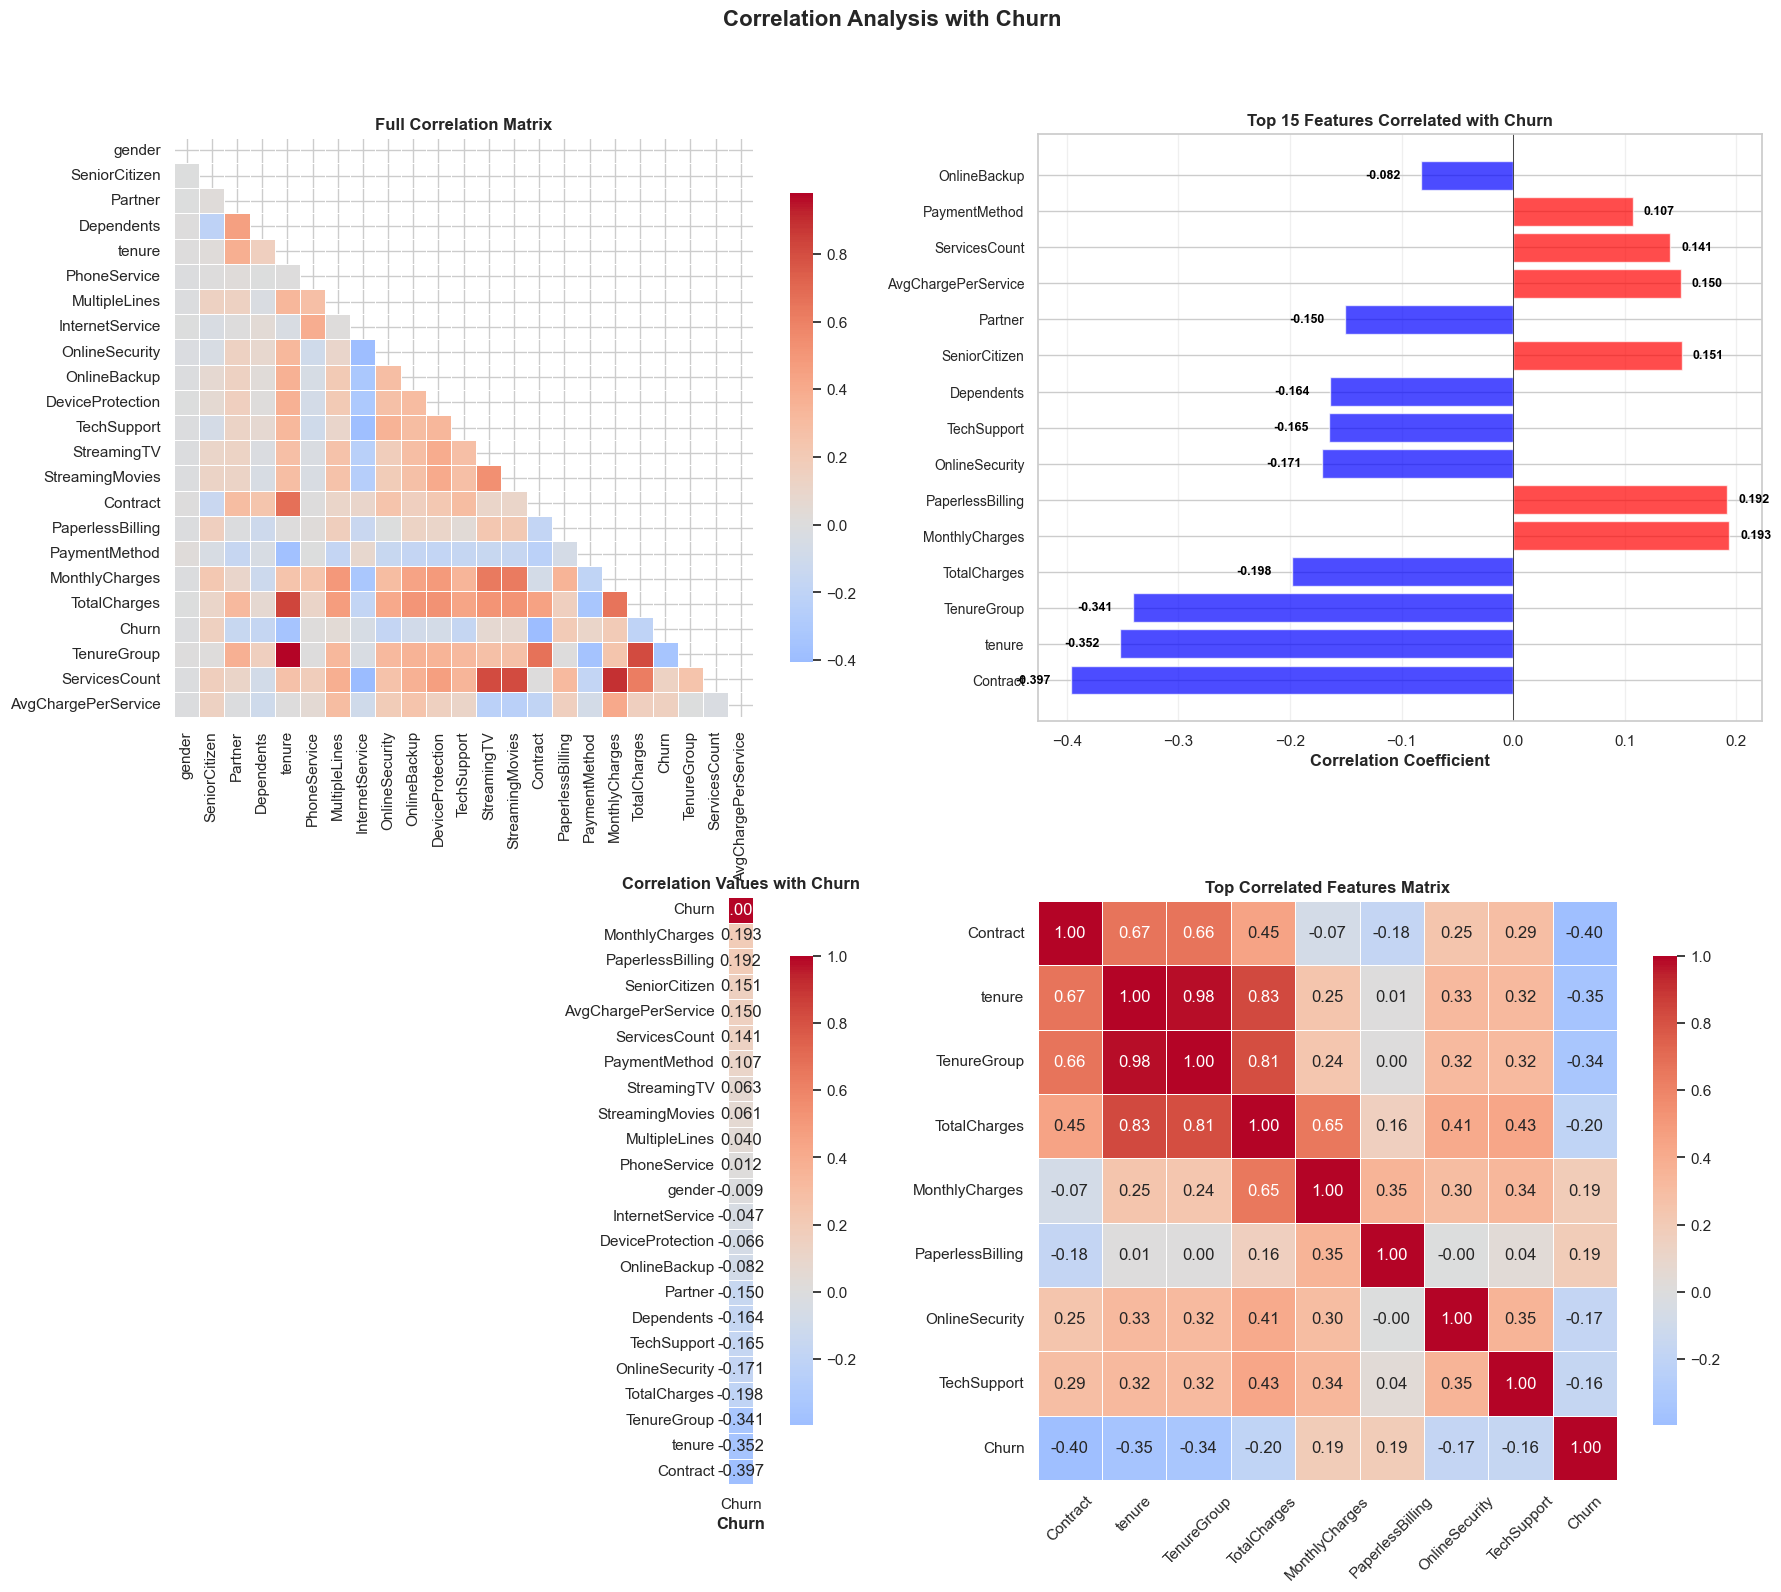

In [28]:
plot_churn_heatmap(correlation_matrix)

1. Generating Churn Distribution...
2. Generating Tenure Distribution by Churn...
3. Generating Monthly Charges Distribution...
4. Generating Contract Type vs Churn...
5. Generating Internet Service vs Churn...
6. Generating Payment Method vs Churn...
7. Generating Senior Citizen vs Churn...
8. Generating Tenure vs Monthly Charges colored by Churn...


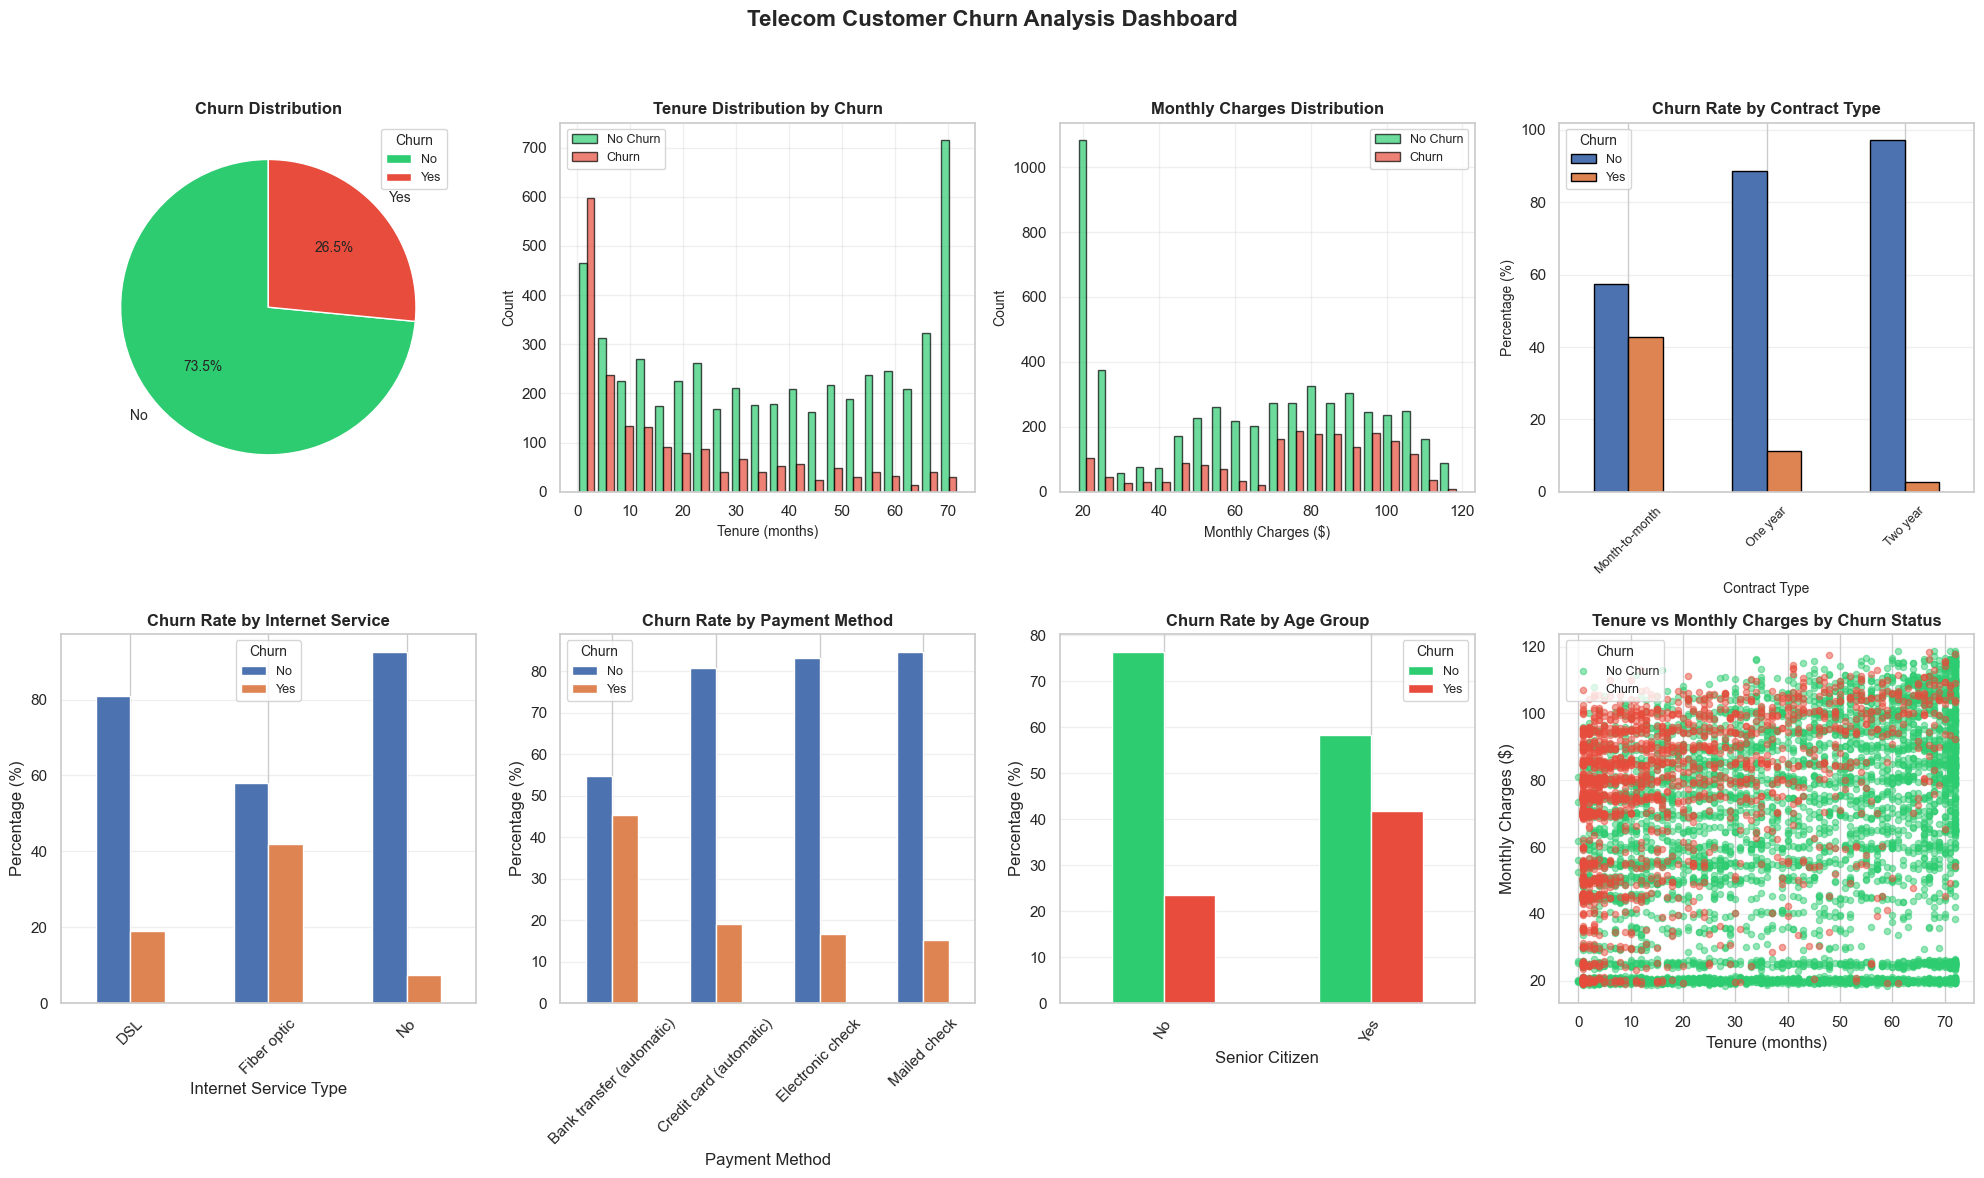

In [29]:
plot_churn_visualization(telecom_plot)

In [30]:
# Create additional detailed visualization
print("\n" + "="*80)
print("ADDITIONAL DETAILED ANALYSIS")
print("="*80)


ADDITIONAL DETAILED ANALYSIS


In [51]:
def plot_churn_additional(correlation_matrix: pd.DataFrame, telecom_plot: pd.DataFrame):
    if correlation_matrix is None or correlation_matrix.empty:
        raise ValueError('Correlation Matrix DataFrame is empty or None')

    if telecom_plot is None or telecom_plot.empty:
        raise ValueError('Telecom DataFrame is empty or None')

    # Create a more detailed correlation visualization
    fig, axes = plt.subplots(2, 2, figsize=(18, 16))
    
    # 1. Correlation matrix with hierarchical clustering
    print("\n1. Generating clustered correlation heatmap...")
    from scipy.cluster import hierarchy

    # Calculate distance matrix
    corr_linkage = hierarchy. linkage(correlation_matrix, method='average')

    # Reorder correlation matrix based on clustering
    order = hierarchy.dendrogram(corr_linkage, no_plot=True)['ivl']
    ordered_corr = correlation_matrix.iloc[[int(i) for i in order], [int(i) for i in order]]

    mask = np.triu(np.ones_like(ordered_corr, dtype=bool))
    sns.heatmap(ordered_corr, mask=mask, cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=axes[0, 0])
    axes[0, 0].set_title('Clustered Correlation Matrix', fontweight='bold', fontsize=14)
    axes[0, 0].tick_params(axis='x', rotation=90)
    axes[0, 0].tick_params(axis='y', rotation=0)

    # 2. Scatter plot matrix for top 3 correlated features
    print("2. Generating scatter plots for top correlated features...")
    top_3_features = churn_correlations.head(3).index.tolist()
    
    # Create subplots for scatter plots
    scatter_data = telecom_plot[top_3_features + ['Churn']].copy()
    scatter_data['Churn_Label'] = telecom_plot['Churn_Label']  # Add original labels for coloring
    scatter_data['TenureGroup_Label'] = telecom_plot['TenureGroup_Label']
    
    # Color mapping
    color_map = {'Yes': 'red', 'No': 'blue'}
    tenure_group_color_map = {'0-1yr': 'red', '1-2yr': 'orange', '2-3yr': 'yellow', '3-4yr': 'green', '4-5yr': 'lime', 
                    '5-6yr': 'blue', '6-7yr': 'purple', '7-8yr': 'indigo', '8-9yr': 'brown', '9-10yr': 'black'}
    
    # Create scatter plots
    for i, feature in enumerate(top_3_features):
        ax = axes[i, 1] if i == 0 else None
        if i == 0:
            for churn_value, color in color_map.items():
                subset = scatter_data[scatter_data['Churn_Label'] == churn_value]
                axes[i, 1].scatter(subset[feature], subset['Churn'], 
                          alpha=0.5, s=30, color=color, label=churn_value)
            axes[i, 1].set_xlabel(feature, fontweight='bold')
            axes[i, 1].set_ylabel('Churn (Encoded)', fontweight='bold')
            axes[i, 1].set_title(f'{feature} vs Churn', fontweight='bold', fontsize=14)
            axes[i, 1].legend(title='Churn', fontsize=9, title_fontsize=10)
            axes[i, 1].grid(True, alpha=0.3)
        elif i == 1:
            for churn_value, color in color_map.items():
                subset = scatter_data[scatter_data['Churn_Label'] == churn_value]
                axes[i, 0].scatter(subset[feature], subset['Churn'], 
                          alpha=0.5, s=30, color=color, label=churn_value)
            axes[i, 0].set_xlabel('Tenure', fontweight='bold')
            axes[i, 0].set_ylabel('Churn (Encoded)', fontweight='bold')
            axes[i, 0].set_title(f'Tenure vs Churn', fontweight='bold', fontsize=14)
            axes[i, 0].tick_params(axis='x', rotation=50)
            axes[i, 0].legend(title='Churn', fontsize=9, title_fontsize=10)
            axes[i, 0].grid(True, alpha=0.3)   
        else:
            for tenure_group_value, color in tenure_group_color_map.items():
                subset = scatter_data[scatter_data['Churn_Label'] == tenure_group_value]
                axes[i - 1, 1].scatter(subset[feature], subset['Churn'], 
                          alpha=0.5, s=30, color=color, label=tenure_group_value)
            axes[i - 1, 1].set_xlabel(feature, fontweight='bold')
            axes[i - 1, 1].set_ylabel('Churn (Encoded)', fontweight='bold')
            axes[i - 1, 1].set_title(f'{feature} vs Churn', fontweight='bold', fontsize=14)
            axes[i - 1, 1].legend(title='Tenure Group', fontsize=9, title_fontsize=10)
            axes[i - 1, 1].grid(True, alpha=0.3)

    # Adjust layout and display ONCE at the end
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return scatter_data


1. Generating clustered correlation heatmap...
2. Generating scatter plots for top correlated features...


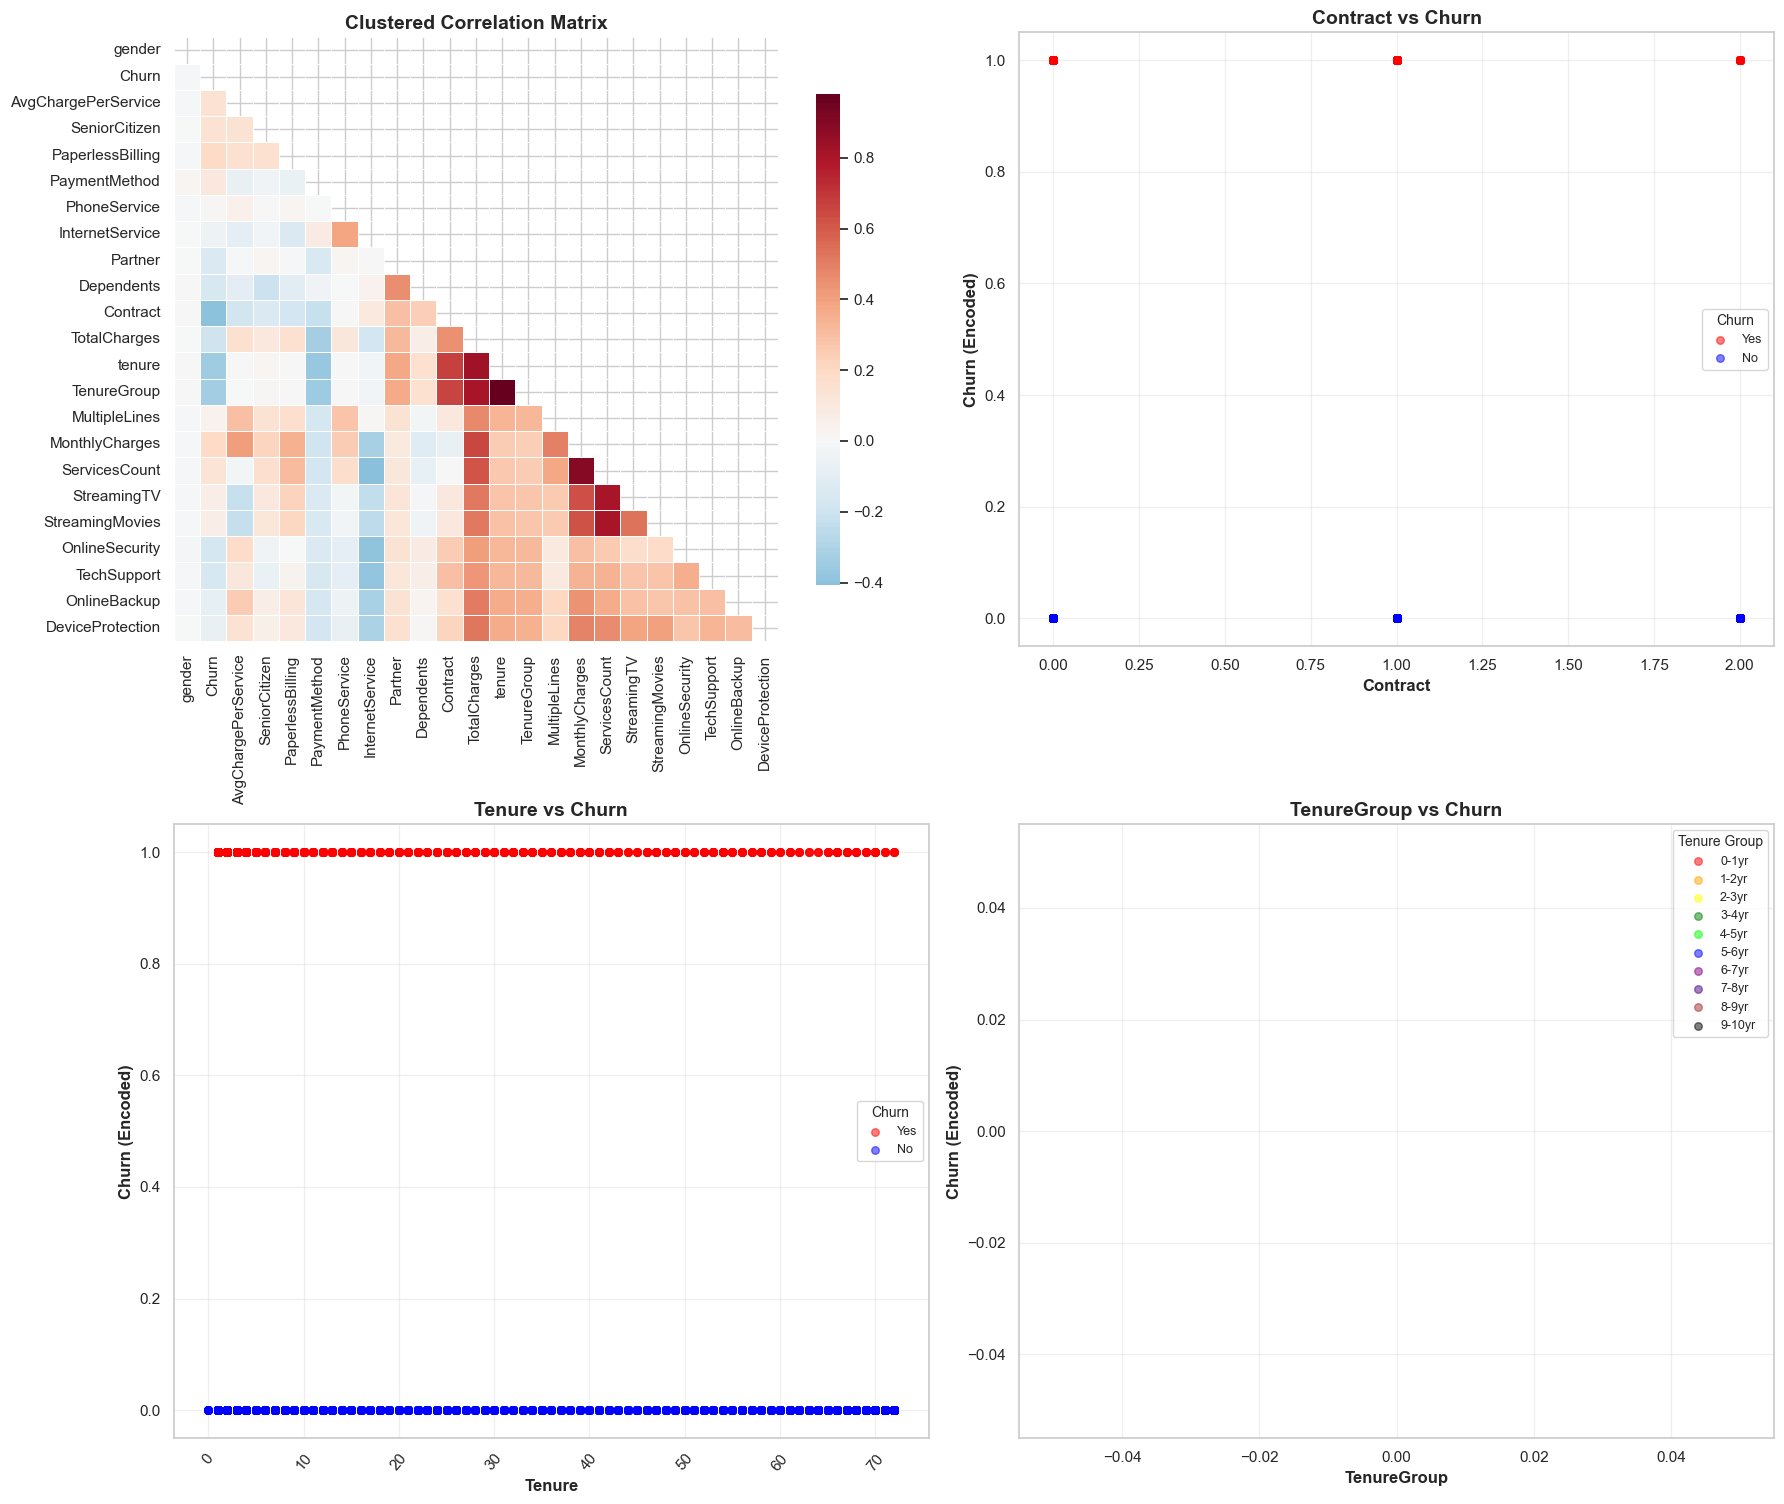

,Contract,tenure,TenureGroup,Churn,Churn_Label,TenureGroup_Label
0,0,1,0,0,No,0-1yr
1,1,34,2,0,No,2-3yr
2,0,2,0,1,Yes,0-1yr
3,1,45,3,0,No,3-4yr
4,0,2,0,1,Yes,0-1yr


In [52]:
scatter_data = plot_churn_additional(correlation_matrix, telecom_plot)
scatter_data.head()